# Penugasan No. 4: Segmentasi Citra dari Internet

## Citra yang Digunakan
Citra yang digunakan adalah **foto apel merah dengan latar belakang putih/polos**
yang diambil dari internet. Citra ini dipilih karena:
- Objek utama (apel) memiliki warna yang kontras dengan latar belakang
- Bentuk objek relatif sederhana namun cukup menantang karena memiliki
  variasi warna (merah, hijau, bayangan)
- Cocok untuk menguji ketiga metode segmentasi secara adil

## Metode yang Diterapkan
| Metode | Pendekatan |
|---|---|
| **Otsu Thresholding** | Global, berbasis intensitas grayscale |
| **K-Means Clustering** | Berbasis pengelompokan warna (ruang Lab) |
| **Watershed** | Berbasis tepi + marker |

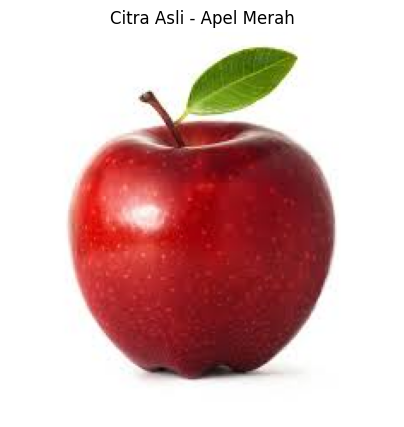

Ukuran citra: (225, 225, 3)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from skimage import io

# Load citra
image_color = io.imread("apple.jpg")

# Tampilkan citra asli
plt.figure(figsize=(5, 5))
plt.imshow(image_color)
plt.title("Citra Asli - Apel Merah")
plt.axis('off')
plt.show()

print(f"Ukuran citra: {image_color.shape}")

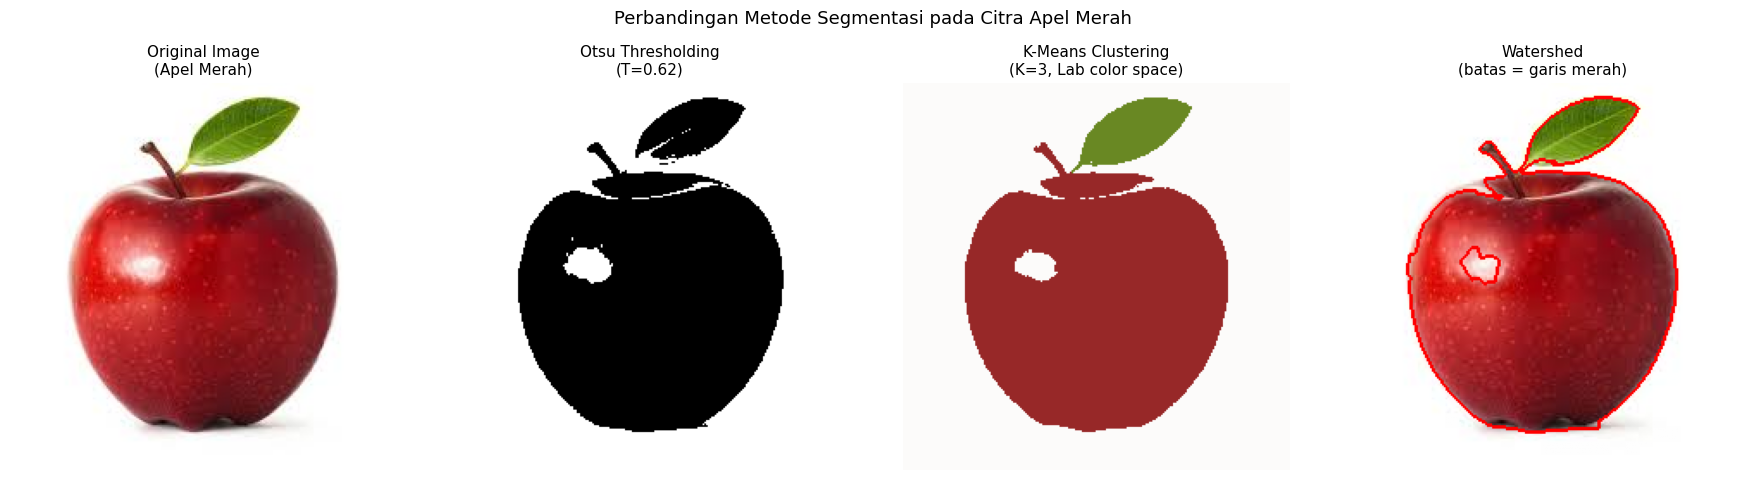

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from skimage import io, filters, segmentation, img_as_float
from skimage.color import rgb2gray, rgb2lab, lab2rgb
from sklearn.cluster import KMeans

# Load ulang citra
image_color = io.imread("apple.jpg")
image_float = img_as_float(image_color)
image_gray  = rgb2gray(image_color)

# ── Metode 1: Otsu Thresholding ──────────────────────────────────────────────
thresh_otsu  = filters.threshold_otsu(image_gray)
binary_otsu  = image_gray > thresh_otsu

# ── Metode 2: K-Means Clustering (K=3, ruang warna Lab) ──────────────────────
image_lab    = rgb2lab(image_float)
rows, cols, dims = image_lab.shape
pixel_features   = image_lab.reshape(rows * cols, dims)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows, cols)

# Rekonstruksi citra hasil K-Means (tiap piksel = warna pusat klasternya)
segmented_kmeans_lab = np.zeros_like(image_lab)
for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_kmeans_lab[mask_k] = kmeans.cluster_centers_[k]
segmented_kmeans_rgb = lab2rgb(segmented_kmeans_lab)

# ── Metode 3: Watershed ───────────────────────────────────────────────────────
elevation_map = filters.sobel(image_gray)

# Buat marker: latar belakang (terang) vs objek (gelap-sedang)
markers = np.zeros_like(image_gray, dtype=int)
markers[image_gray > 0.85] = 1   # latar belakang putih
markers[image_gray < 0.60] = 2   # objek apel

segmentation_ws      = segmentation.watershed(elevation_map, markers)
segmented_ws_colored = segmentation.mark_boundaries(
    image_float, segmentation_ws, color=(1, 0, 0)
)

# ── Visualisasi Perbandingan ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
ax = axes.ravel()

ax[0].imshow(image_color)
ax[0].set_title('Original Image\n(Apel Merah)', fontsize=11)
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Thresholding\n(T={thresh_otsu:.2f})', fontsize=11)
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_rgb)
ax[2].set_title(f'K-Means Clustering\n(K={n_clusters}, Lab color space)', fontsize=11)
ax[2].axis('off')

ax[3].imshow(segmented_ws_colored)
ax[3].set_title('Watershed\n(batas = garis merah)', fontsize=11)
ax[3].axis('off')

plt.suptitle('Perbandingan Metode Segmentasi pada Citra Apel Merah', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

## Analisis Perbandingan Hasil

### 1. Otsu Thresholding
Bekerja pada citra **grayscale**, sehingga informasi warna hilang. Pada citra apel,
metode ini cukup berhasil memisahkan apel dari latar belakang putih karena kontras
intensitasnya cukup jelas. Namun bagian apel yang memiliki highlight terang
(pantulan cahaya) bisa ikut terpotong dan dianggap latar belakang.

**Kelebihan:** Cepat, sederhana
**Kekurangan:** Tidak memanfaatkan informasi warna, highlight ikut terpotong

### 2. K-Means Clustering (K=3)
Bekerja pada ruang warna **Lab**, sehingga mampu membedakan:
- Klaster 1 → latar belakang putih
- Klaster 2 → area merah apel
- Klaster 3 → area bayangan/tangkai

Hasilnya paling informatif secara warna karena setiap segmen direpresentasikan
dengan warna rata-rata klasternya. Sangat cocok untuk citra berwarna.

**Kelebihan:** Memanfaatkan informasi warna, menghasilkan beberapa segmen sekaligus
**Kekurangan:** Perlu menentukan K, hasil bisa berbeda tiap eksekusi

### 3. Watershed
Mendeteksi **batas tepi** objek menggunakan gradien Sobel, lalu memisahkan region
berdasarkan marker. Pada citra apel, batas antara apel dan latar belakang terdeteksi
dengan cukup baik ditandai garis merah.

**Kelebihan:** Batas objek terdeteksi detail
**Kekurangan:** Sensitif terhadap pemilihan marker, bisa over-segmentasi

---

## Kesimpulan Penugasan No. 4

| Metode | Kecocokan untuk Citra Apel | Alasan |
|---|---|---|
| Otsu | ⭐⭐⭐ Cukup | Kontras cukup jelas, tapi info warna hilang |
| K-Means | ⭐⭐⭐⭐⭐ Terbaik | Memanfaatkan warna, segmentasi paling natural |
| Watershed | ⭐⭐⭐⭐ Baik | Batas objek jelas, cocok jika marker tepat |

**Metode terbaik untuk citra apel merah adalah K-Means Clustering** karena:
1. Citra apel memiliki variasi warna yang kaya (merah, hijau, putih, bayangan)
2. K-Means bekerja di ruang warna Lab yang sesuai persepsi manusia
3. Mampu memisahkan latar belakang, objek utama, dan bayangan sekaligus
   tanpa kehilangan informasi warna seperti pada Otsu